In [4]:
# Import neccessary packages

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import gudhi
from gudhi import RipsComplex
from gudhi.representations import PersistenceImage
from sklearn.model_selection import train_test_split
import torch 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import pandas as pd
import seaborn as sns 

In [16]:
def k_means_clustering(data, cluster_size):
    kmeans = KMeans(n_clusters=cluster_size, random_state=42).fit(data)
    centroids = kmeans.cluster_centers_
    rep_id = pairwise_distances_argmin(centroids, data)
    clustering = data[rep_id]
    return clustering

feature_list = ["u","g","redshift"]

label_dict = {"GALAXY":0,"QSO":1,"STAR":2}

data = pd.read_csv("star_classification.csv")

'''
for feature in data[feature_list].columns:
    mean = data[feature].mean()
    std = data[feature].std()
    data = data[abs(data[feature] - mean) <= 4 * std]
'''

scaler = StandardScaler()
data[feature_list] = scaler.fit_transform(data[feature_list])
threshold = 4
data = data[~ (data[feature_list]**2 > threshold**2).any(axis=1)]


data["redshift"] = 1/(1+data["redshift"])


X = data[feature_list].to_numpy()
y = data["class"].replace(label_dict).to_numpy()


data

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,0.059755,0.054926,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.926306,5812,56354,171
1,1.237665e+18,144.826101,31.274185,0.088045,0.072456,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.783026,10445,58158,427
2,1.237661e+18,142.188790,35.582444,0.103327,0.067165,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.915396,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,0.004921,0.102210,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.672599,9149,58039,775
4,1.237680e+18,345.282593,21.183866,-0.080055,-0.092948,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,2.704652,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,0.005890,0.076991,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,4.743510,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,0.022371,0.058422,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,1.307308,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,-0.025538,-0.039730,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,2.456903,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,0.106075,0.034840,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,1.199679,6751,56368,470


In [ ]:
img_res = 20
num_of_classes = len(np.unique(y))
input_dim = len(X[0])


train_features, test_features, train_targets, test_targets = train_test_split(
                                                X, 
                                                y, 
                                                test_size=0.1, 
                                                random_state=2)


validation_features, test_features, validation_targets, test_targets = train_test_split(
                                                    test_features, 
                                                    test_targets, 
                                                    test_size=0.5, 
                                                    random_state=2)



def gen_persistence_image(input, cluster):
    point_cloud = np.vstack((input,cluster))
    rips = RipsComplex(points = point_cloud)
    simplex_tree = rips.create_simplex_tree(max_dimension=2)
    diag = simplex_tree.persistence()
    diag_intervals = np.array([i[1] for i in diag if i[1][1] != np.inf])
    PI = PersistenceImage(resolution=[img_res, img_res]).fit_transform([diag_intervals])
    return PI

# Sorting our features by label
galaxies = train_features[train_targets == 0] #GALAXY
quasars = train_features[train_targets == 1] #QSO
stars = train_features[train_targets == 2 ] #STAR

data_by_cat = [galaxies, quasars, stars]

#Sampling 50 example points from each category
galaxy_sample = k_means_clustering(galaxies, 50)
quasar_sample = k_means_clustering(quasars, 50)
star_sample = k_means_clustering(stars, 50)

clusters = [galaxy_sample,quasar_sample,star_sample]

#Initializing our feature arrays to fill with persistence images
X_train = np.zeros((len(train_features),num_of_classes,img_res*img_res))
X_validation = np.zeros((len(validation_features),num_of_classes,img_res*img_res))
X_test = np.zeros((len(test_features),num_of_classes,img_res*img_res))

for X,y in [(train_features,X_train),(test_features,X_test),(validation_features,X_validation)]:
    for i in range(len(X)):
        for j in range(num_of_classes):
            y[i][j] = gen_persistence_image(X[i],clusters[j])


train_features = np.reshape(X_train, (len(X_train), 3, img_res, img_res))
validation_features = np.reshape(X_validation, (len(X_validation), 3, img_res, img_res))
test_features = np.reshape(X_test, (len(X_test), 3, img_res, img_res))


'''
print(train_features.shape)
print(validation_features.shape)
print(test_features.shape)
print(train_targets)
'''


'\n#Initializing our feature arrays to fill with persistence images\nX_train = np.zeros((len(train_features),num_of_classes,img_res*img_res))\nX_validation = np.zeros((len(validation_features),num_of_classes,img_res*img_res))\nX_test = np.zeros((len(test_features),num_of_classes,img_res*img_res))\n\nfor X,y in [(train_features,X_train),(test_features,X_test),(validation_features,X_validation)]:\n    for i in range(len(X)):\n        for j in range(num_of_classes):\n            y[i][j] = gen_persistence_image(X[i],clusters[j])\n\n\ntrain_features = np.reshape(X_train, (len(X_train), 3, img_res, img_res))\nvalidation_features = np.reshape(X_validation, (len(X_validation), 3, img_res, img_res))\ntest_features = np.reshape(X_test, (len(X_test), 3, img_res, img_res))\n\n\n\nprint(train_features.shape)\nprint(validation_features.shape)\nprint(test_features.shape)\nprint(train_targets)\n'

In [19]:
import plotly.graph_objects as go

i = 2
j = 1
k = 0

# Create the figure
fig = go.Figure()


fig.add_trace(go.Scatter3d(
    x=data_by_cat[i][:,0],
    y=data_by_cat[i][:,1], 
    z=data_by_cat[i][:,2],
    mode='markers',
    marker=dict(size=1, color='red'),
    name='Plot 1'
))

fig.add_trace(go.Scatter3d(
    x=data_by_cat[j][:,0], 
    y=data_by_cat[j][:,1], 
    z=data_by_cat[j][:,2],
    mode='markers',
    marker=dict(size=1, color='purple'),
    name='Plot 2'
))

fig.add_trace(go.Scatter3d(
    x=data_by_cat[k][:,0], 
    y=data_by_cat[k][:,1], 
    z=data_by_cat[k][:,2],
    mode='markers',
    marker=dict(size=1, color='pink'),
    name='Plot 2'
))


fig.add_trace(go.Scatter3d(
    x=clusters[i][:,0], 
    y=clusters[i][:,1], 
    z=clusters[i][:,2],
    mode='markers',
    marker=dict(size=4, color='blue'),
    name='Plot 2'
))

fig.add_trace(go.Scatter3d(
    x=clusters[j][:,0], 
    y=clusters[j][:,1], 
    z=clusters[j][:,2],
    mode='markers',
    marker=dict(size=4, color='green'),
    name='Plot 2'
))

fig.add_trace(go.Scatter3d(
    x=clusters[k][:,0], 
    y=clusters[k][:,1], 
    z=clusters[k][:,2],
    mode='markers',
    marker=dict(size=4, color='orange'),
    name='Plot 2'
))

fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.show()

1


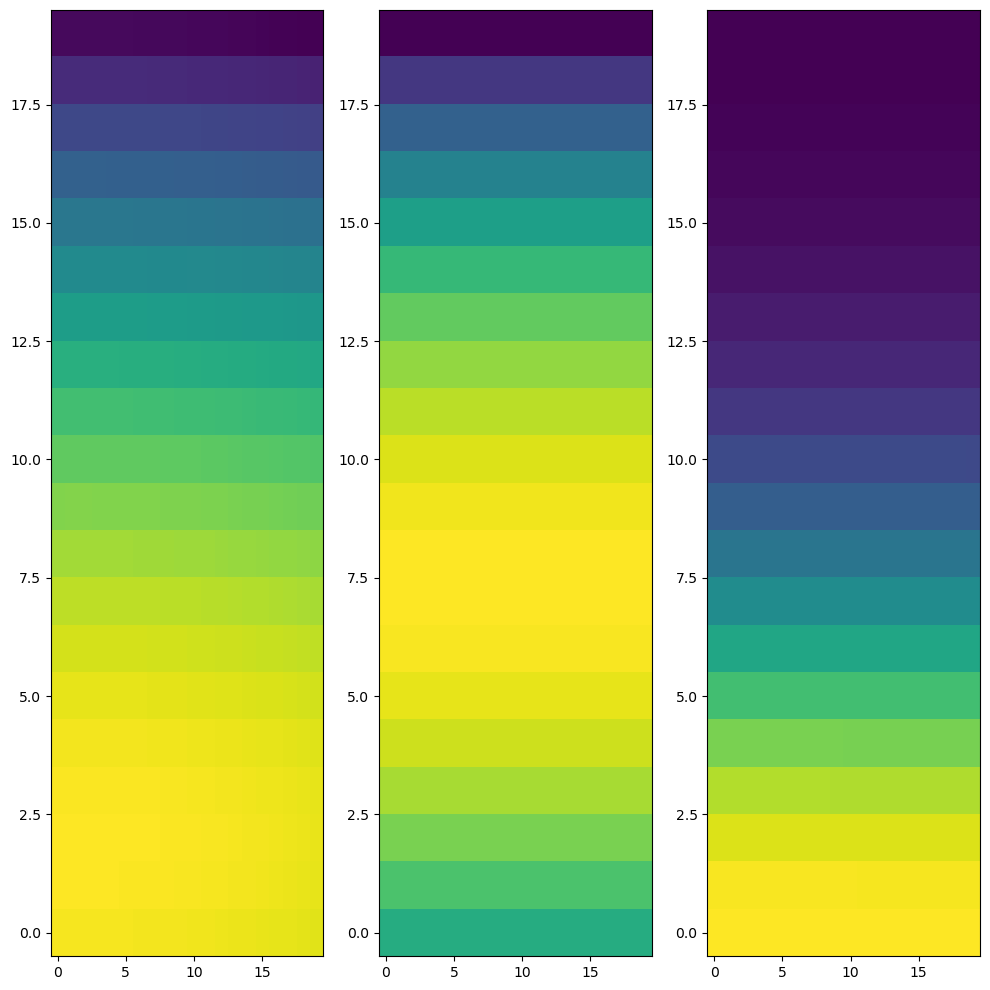

In [7]:
#Visualizing a random triple of persistence images associated with the features at index i in our training set

i = 13
plt.figure(figsize=(10, 10))
plt.subplot(1,3,1)
plt.imshow(train_features[i][0], origin="lower", cmap="viridis", aspect="auto")

plt.subplot(1,3,2)
plt.imshow(train_features[i][1], origin="lower", cmap="viridis", aspect="auto")

plt.subplot(1,3,3)
plt.imshow(train_features[i][2], origin="lower", cmap="viridis", aspect="auto")

plt.tight_layout()
print(train_targets[i])
plt.show()

In [8]:
import torch.nn as nn

class simpleCNN(nn.Module):
    def __init__(self, num_channels, num_of_classes, image_res, hidden_layer_size):

        super(simpleCNN, self).__init__()
        # We seperate our layers into blocks 

        #The convolutional block consists of two convolutional layers,
        self.conv_layers = nn.Sequential(
            nn.Conv2d(num_channels, num_channels, kernel_size=3, padding=1),
            #nn.Conv2d(4, 8, kernel_size=3, padding=1),
        )

        # The fully connected block 
        # three layers with linear activation and dropout for regularization
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_channels * img_res * img_res, hidden_layer_size),
            nn.Dropout(0.3),
            nn.Linear(hidden_layer_size, num_of_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [9]:
train_targets

array([0, 0, 0, ..., 0, 1, 2], shape=(89512,), dtype=object)

In [ ]:
model = simpleCNN(
    num_channels = 3, 
    num_of_classes = 3, 
    image_res = img_res,
    hidden_layer_size = 20,
    
)

# (3) channels * (3*3) convolutional window * (20*20) image resolution = 10800
# (3 * 20 * 20) from convolutional layer * (20) hidden layer size = 24000
# 20 * 3 for output = 60



learning_rate = 0.0001
epochs  = 15


loss_func = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

train_loss_list = []
validation_accuracy_list = np.zeros((epochs,))

In [ ]:
# Convert the training, validation, testing dataset (NumPy arrays) into torch tensors
# Split your training features/targets into mini-batches if using mini-batch gradient

train_inputs = torch.from_numpy(train_features).float()
train_targets = torch.from_numpy(train_targets.astype(int))

validation_inputs = torch.from_numpy(validation_features).float()
validation_targets = torch.from_numpy(validation_targets.astype(int))

testing_inputs = torch.from_numpy(test_features).float()
testing_targets = torch.from_numpy(test_targets.astype(int)) 



In [12]:
batchsize = 1000

# Use torch.split() function to split the training inputs/targets into mini-batches
train_batches_features = torch.split(train_inputs, batchsize)
train_batches_targets = torch.split(train_targets, batchsize)

# length of train_batches_features = total number of mini-batches in the training set
batch_split_num = len(train_batches_features)


In [13]:
import tqdm # Use "for epoch in tqdm.trange(epochs):" to see the progress bar


for epoch in range(epochs):
    model.train() # Set the model to training mode
    
    for k in range(batch_split_num):
    
        optimizer.zero_grad()
            
        train_batch_outputs = model(train_batches_features[k])

        loss = loss_func(train_batch_outputs, train_batches_targets[k])

        train_loss_list.append(loss.item())

        loss.backward()

        optimizer.step()

    # Compute Validation Accuracy ----------------------------------------------------------------------

    with torch.no_grad():
        model.eval() # Set the model to evaluation mode to turn off dropout layers

        validation_outputs = model(validation_inputs)

        correct = (torch.argmax(validation_outputs, dim=1) == 
                   validation_targets).type(torch.FloatTensor)
        
        validation_accuracy = np.round(correct.mean().numpy() * 100, 2)
        
        print("Epoch: "+ str(epoch), 
              "Validation Accuracy: " + str(validation_accuracy) + '%', flush=True)
        
        
        

        validation_accuracy_list[epoch] = correct.mean()


Epoch: 0 Validation Accuracy: 72.33%
Epoch: 1 Validation Accuracy: 72.71%
Epoch: 2 Validation Accuracy: 72.85%
Epoch: 3 Validation Accuracy: 81.2%
Epoch: 4 Validation Accuracy: 81.28%
Epoch: 5 Validation Accuracy: 82.28%
Epoch: 6 Validation Accuracy: 81.6%
Epoch: 7 Validation Accuracy: 80.94%
Epoch: 8 Validation Accuracy: 79.87%
Epoch: 9 Validation Accuracy: 78.99%
Epoch: 10 Validation Accuracy: 78.71%
Epoch: 11 Validation Accuracy: 78.36%
Epoch: 12 Validation Accuracy: 79.89%
Epoch: 13 Validation Accuracy: 78.66%
Epoch: 14 Validation Accuracy: 79.77%


Text(0, 0.5, 'validation accuracy')

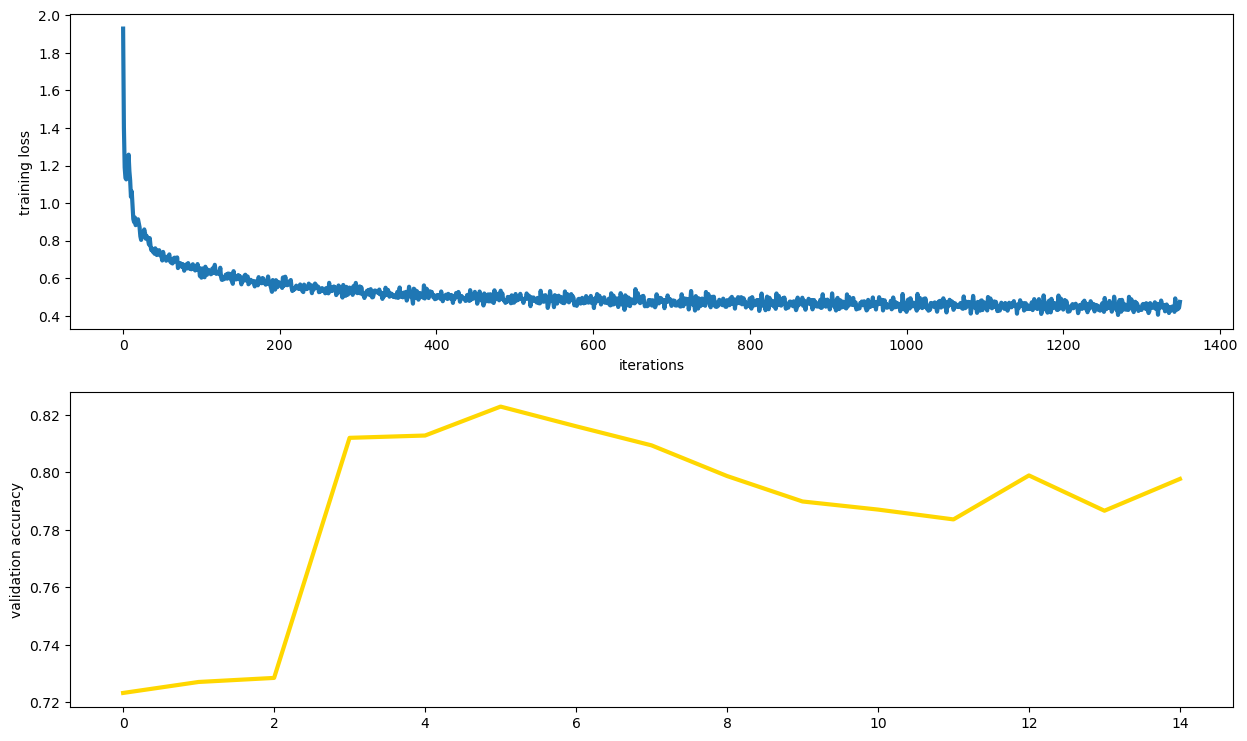

In [14]:


plt.figure(figsize = (15, 9))

plt.subplot(2, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.ylabel("training loss")
plt.xlabel("iterations")


plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.ylabel("validation accuracy")


Testing Accuracy: 0.79589784


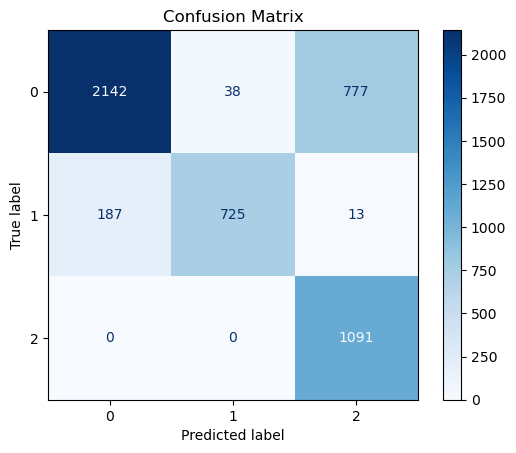

In [15]:
# Compute the testing accuracy 

with torch.no_grad():
    model.eval() # Set the model to evaluation mode to turn off dropout layers
    
    y_pred_test = model(testing_inputs)
     
    correct = (torch.argmax(y_pred_test, dim=1) == testing_targets).type(torch.FloatTensor)
    
    print("Testing Accuracy: " + str(correct.mean().numpy()))


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(testing_targets, torch.argmax(y_pred_test, dim=1))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

Computing Alternatives/baselines
2) standard scaling but then scale the redshift by 1(1+x) 
3) standardized implementation of logistic regression
4) fully connected neural net on the original data

Images:
Example of 

Justify why images could extract interesting features
* Category sampled from a thicked parameterized link in R^3


